In [14]:
!pip install -U ultralytics

   ---------------------------------------- 0.0/994.0 kB ? eta -:--:--
   --------------------------------------- 994.0/994.0 kB 15.6 MB/s eta 0:00:00
  Attempting uninstall: ultralytics
    Found existing installation: ultralytics 8.3.98
    Uninstalling ultralytics-8.3.98:
      Successfully uninstalled ultralytics-8.3.98


In [15]:
import os
import yaml
import cv2
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import precision_score, recall_score, f1_score
from ultralytics import YOLO

# 📂 Caminhos do dataset BDD100K convertidos para YOLO
dataset_root = r"C:\Users\Jorge Cunha\Desktop\Python\AI_Detection_Cars\AAU2\Test\yolo_dataset"
dataset_yaml = {
    "train": os.path.join(dataset_root, "images/train"),
    "val": os.path.join(dataset_root, "images/validation"),
    "test": os.path.join(dataset_root, "images/test"),
    "nc": 10,
    "names": [
        "traffic sign", "traffic light", "car", "rider", "motor",
        "person", "bus", "truck", "bike", "train"
    ]
}

# 📝 Salva o YAML do dataset
yaml_path = os.path.join(dataset_root, "bdd100k_dataset.yaml")
with open(yaml_path, "w") as f:
    yaml.dump(dataset_yaml, f)

# 🔍 Detecta se há GPU disponível
device = "0" if torch.cuda.is_available() else "cpu"
print(f"💻 Usando dispositivo: {'GPU' if device == '0' else 'CPU'}")

# 🚀 Treinamento YOLOv8
model = YOLO("yolov8n.pt")
model.train(
    data=yaml_path,
    epochs=400,
    imgsz=640,
    batch=16,
    name="bdd100k_finetuned",
    workers=2,
    patience=50,
    device=device,
    verbose=True
)


💻 Usando dispositivo: GPU
New https://pypi.org/project/ultralytics/8.3.103 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.98  Python-3.12.9 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 Ti Laptop GPU, 4096MiB)
engine\trainer: task=detect, mode=train, model=yolov8n.pt, data=C:\Users\Jorge Cunha\Desktop\Python\AI_Detection_Cars\AAU2\Test\yolo_dataset\bdd100k_dataset.yaml, epochs=400, time=None, patience=50, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=2, project=None, name=bdd100k_finetuned2, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buf

train: Scanning C:\Users\Jorge Cunha\Desktop\Python\AI_Detection_Cars\AAU2\Test\yolo_dataset\labels\train.cache... 1154 images, 1 backgrounds, 0 corrupt: 100%|██████████| 1154/1154 [00:00<?, ?it/s]
val: Scanning C:\Users\Jorge Cunha\Desktop\Python\AI_Detection_Cars\AAU2\Test\yolo_dataset\labels\validation.cache... 10000 images, 1 backgrounds, 0 corrupt: 100%|██████████| 10000/10000 [00:00<?, ?it/s]


Plotting labels to runs\detect\bdd100k_finetuned2\labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.000714, momentum=0.9) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)
Image sizes 640 train, 640 val
Using 2 dataloader workers
Logging results to runs\detect\bdd100k_finetuned2
Starting training for 400 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


      1/400      3.06G      1.783      2.739      1.155        143        640: 100%|██████████| 73/73 [00:15<00:00,  4.58it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 313/313 [01:01<00:00,  5.12it/s]


                   all      10000     170805        0.6     0.0588      0.107     0.0611

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

    100/400      2.45G      1.239     0.7412     0.9599         37        640: 100%|██████████| 73/73 [00:16<00:00,  4.55it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 313/313 [01:02<00:00,  5.00it/s]


                   all      10000     170805      0.391      0.281      0.271      0.143
EarlyStopping: Training stopped early as no improvement observed in last 50 epochs. Best results observed at epoch 50, best model saved as best.pt.
To update EarlyStopping(patience=50) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.

100 epochs completed in 2.190 hours.
Optimizer stripped from runs\detect\bdd100k_finetuned2\weights\last.pt, 6.2MB
Optimizer stripped from runs\detect\bdd100k_finetuned2\weights\best.pt, 6.2MB

Validating runs\detect\bdd100k_finetuned2\weights\best.pt...
Ultralytics 8.3.98  Python-3.12.9 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 Ti Laptop GPU, 4096MiB)
Model summary (fused): 72 layers, 3,007,598 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 313/313 [01:14<00:00,  4.20it/s]


                   all      10000     170805      0.528      0.274      0.271      0.146
         traffic light        515        649      0.185      0.111     0.0665     0.0265
                   car       9879     102506      0.628      0.589      0.623      0.364
                 rider       2689       4245      0.398      0.315      0.286      0.186
                 motor       1242       1597      0.418      0.307      0.287        0.2
                person         14         15          1          0          0          0
                  bike       5653      26885      0.524       0.28        0.3     0.0933
                 train       8221      34908      0.541      0.319      0.334      0.155
Speed: 0.2ms preprocess, 1.7ms inference, 0.0ms loss, 0.9ms postprocess per image
Results saved to runs\detect\bdd100k_finetuned2


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([1, 2, 3, 4, 5, 8, 9])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x0000021198A38200>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047

Ultralytics 8.3.98  Python-3.12.9 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 Ti Laptop GPU, 4096MiB)
Model summary (fused): 72 layers, 3,007,598 parameters, 0 gradients, 8.1 GFLOPs


val: Scanning C:\Users\Jorge Cunha\Desktop\Python\AI_Detection_Cars\AAU2\Test\yolo_dataset\labels\validation.cache... 10000 images, 1 backgrounds, 0 corrupt: 100%|██████████| 10000/10000 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 625/625 [01:50<00:00,  5.65it/s]


                   all      10000     170805      0.529      0.274      0.271      0.146
         traffic light        515        649      0.188      0.111     0.0656     0.0264
                   car       9879     102506      0.631      0.589      0.624      0.364
                 rider       2689       4245      0.399      0.315      0.286      0.186
                 motor       1242       1597      0.417      0.305      0.287        0.2
                person         14         15          1          0          0          0
                  bike       5653      26885      0.527      0.279      0.301     0.0937
                 train       8221      34908      0.543      0.318      0.334      0.155
Speed: 0.2ms preprocess, 3.0ms inference, 0.0ms loss, 0.9ms postprocess per image
Saving runs\detect\val2\predictions.json...
Results saved to runs\detect\val2
🖼️ Imagem: b1c66a42-6f7d68ca.jpg

image 1/1 C:\Users\Jorge Cunha\Desktop\Python\AI_Detection_Cars\AAU2\Test\yolo_dataset\images\

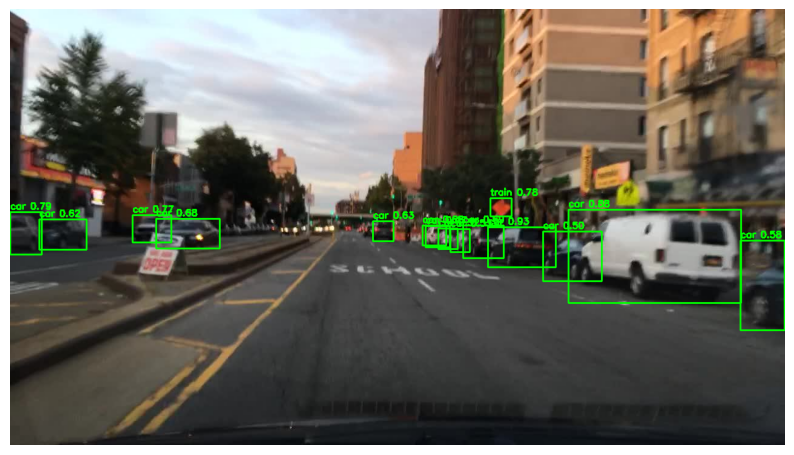

🖼️ Imagem: b1c81faa-3df17267.jpg

image 1/1 C:\Users\Jorge Cunha\Desktop\Python\AI_Detection_Cars\AAU2\Test\yolo_dataset\images\validation\b1c81faa-3df17267.jpg: 384x640 3 cars, 1 bike, 1 train, 8.7ms
Speed: 1.3ms preprocess, 8.7ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)


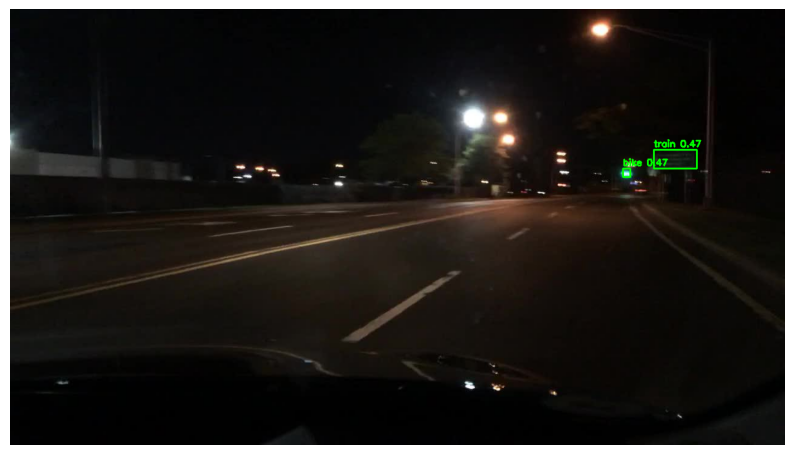

🖼️ Imagem: b1c81faa-c80764c5.jpg

image 1/1 C:\Users\Jorge Cunha\Desktop\Python\AI_Detection_Cars\AAU2\Test\yolo_dataset\images\validation\b1c81faa-c80764c5.jpg: 384x640 2 cars, 2 trains, 6.6ms
Speed: 1.5ms preprocess, 6.6ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)


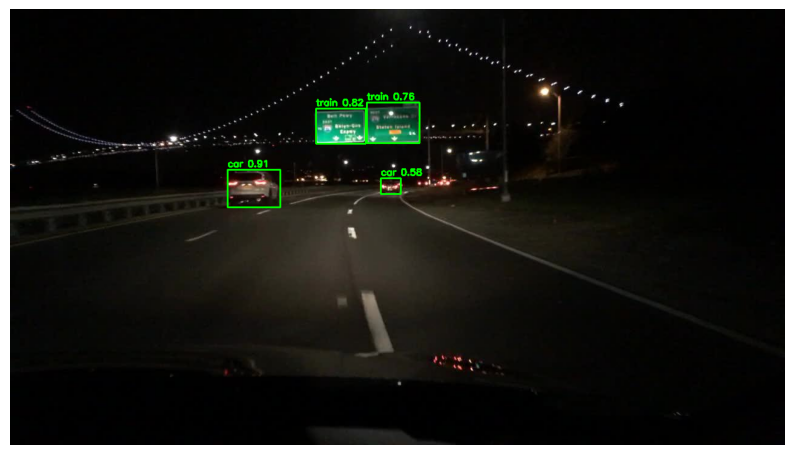

🖼️ Imagem: b1c9c847-3bda4659.jpg

image 1/1 C:\Users\Jorge Cunha\Desktop\Python\AI_Detection_Cars\AAU2\Test\yolo_dataset\images\validation\b1c9c847-3bda4659.jpg: 384x640 21 cars, 11.8ms
Speed: 2.9ms preprocess, 11.8ms inference, 3.2ms postprocess per image at shape (1, 3, 384, 640)


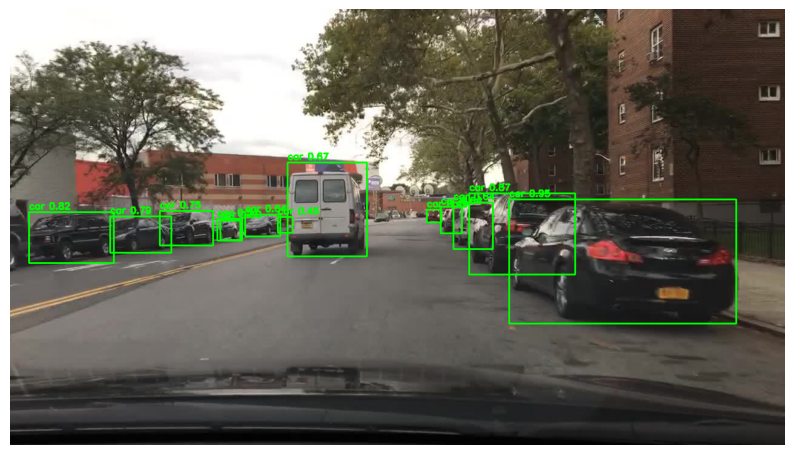

🖼️ Imagem: b1ca2e5d-84cf9134.jpg

image 1/1 C:\Users\Jorge Cunha\Desktop\Python\AI_Detection_Cars\AAU2\Test\yolo_dataset\images\validation\b1ca2e5d-84cf9134.jpg: 384x640 7 cars, 2 bikes, 1 train, 5.9ms
Speed: 1.3ms preprocess, 5.9ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)


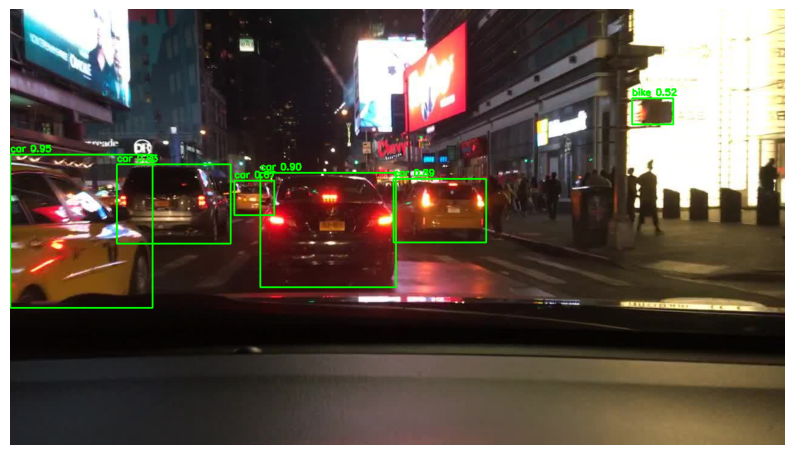

🖼️ Imagem: b1ca8418-84a133a0.jpg

image 1/1 C:\Users\Jorge Cunha\Desktop\Python\AI_Detection_Cars\AAU2\Test\yolo_dataset\images\validation\b1ca8418-84a133a0.jpg: 384x640 2 cars, 1 bike, 3 trains, 7.7ms
Speed: 1.5ms preprocess, 7.7ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)


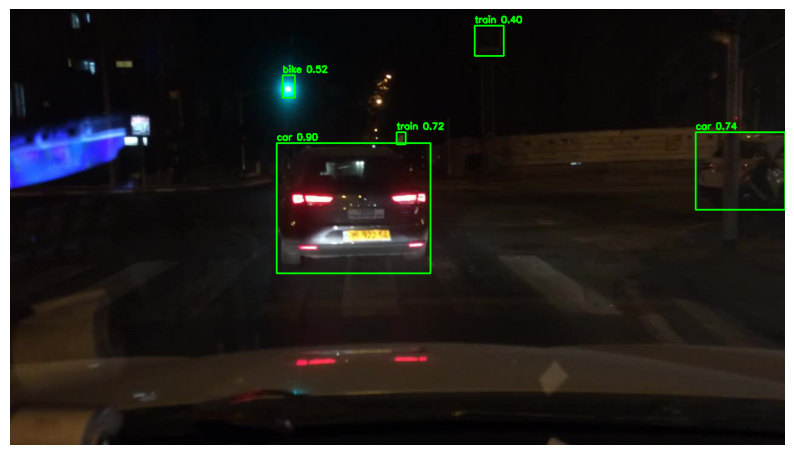

🖼️ Imagem: b1cac6a7-04e33135.jpg

image 1/1 C:\Users\Jorge Cunha\Desktop\Python\AI_Detection_Cars\AAU2\Test\yolo_dataset\images\validation\b1cac6a7-04e33135.jpg: 384x640 13 cars, 11.8ms
Speed: 1.6ms preprocess, 11.8ms inference, 3.0ms postprocess per image at shape (1, 3, 384, 640)


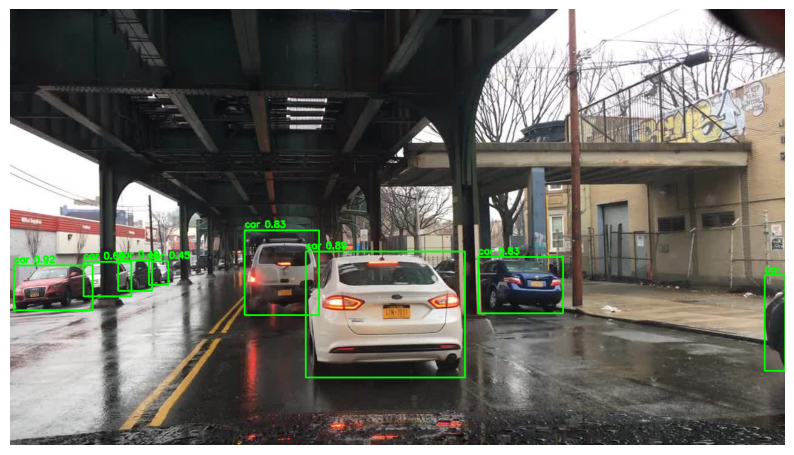

🖼️ Imagem: b1cd1e94-26dd524f.jpg

image 1/1 C:\Users\Jorge Cunha\Desktop\Python\AI_Detection_Cars\AAU2\Test\yolo_dataset\images\validation\b1cd1e94-26dd524f.jpg: 384x640 7 cars, 3 bikes, 2 trains, 6.3ms
Speed: 1.3ms preprocess, 6.3ms inference, 3.5ms postprocess per image at shape (1, 3, 384, 640)


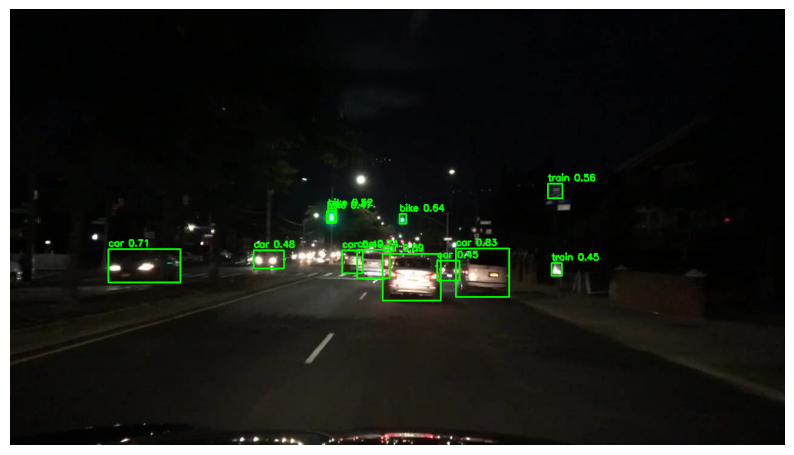

🖼️ Imagem: b1cd1e94-549d0bfe.jpg

image 1/1 C:\Users\Jorge Cunha\Desktop\Python\AI_Detection_Cars\AAU2\Test\yolo_dataset\images\validation\b1cd1e94-549d0bfe.jpg: 384x640 7 cars, 1 motor, 2 bikes, 2 trains, 6.0ms
Speed: 1.5ms preprocess, 6.0ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)


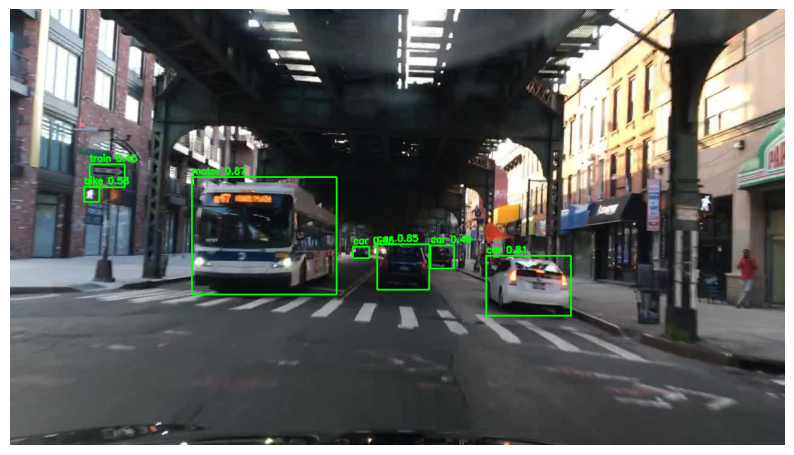

🖼️ Imagem: b1ceb32e-3f481b43.jpg

image 1/1 C:\Users\Jorge Cunha\Desktop\Python\AI_Detection_Cars\AAU2\Test\yolo_dataset\images\validation\b1ceb32e-3f481b43.jpg: 384x640 7 cars, 6.0ms
Speed: 1.3ms preprocess, 6.0ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)


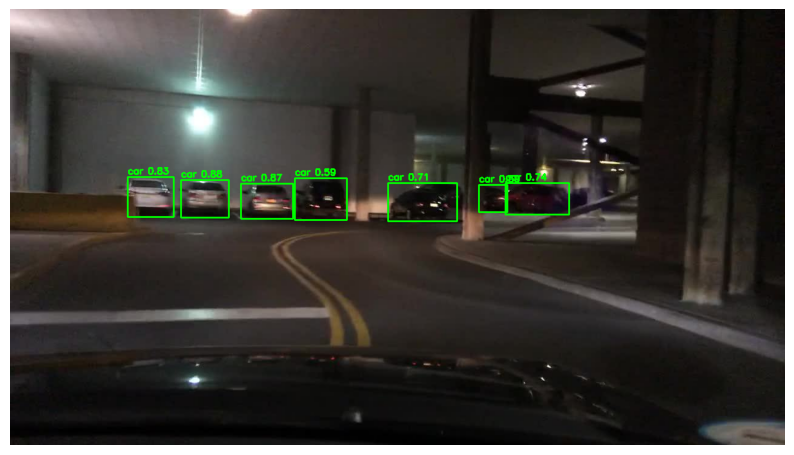

  0%|          | 0/100 [00:00<?, ?it/s]


image 1/1 C:\Users\Jorge Cunha\Desktop\Python\AI_Detection_Cars\AAU2\Test\yolo_dataset\images\validation\b1c66a42-6f7d68ca.jpg: 384x640 21 cars, 3 trains, 10.5ms
Speed: 1.5ms preprocess, 10.5ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 C:\Users\Jorge Cunha\Desktop\Python\AI_Detection_Cars\AAU2\Test\yolo_dataset\images\validation\b1c81faa-3df17267.jpg: 384x640 3 cars, 1 bike, 1 train, 10.9ms
Speed: 1.1ms preprocess, 10.9ms inference, 2.3ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 C:\Users\Jorge Cunha\Desktop\Python\AI_Detection_Cars\AAU2\Test\yolo_dataset\images\validation\b1c81faa-c80764c5.jpg: 384x640 2 cars, 2 trains, 11.4ms
Speed: 1.5ms preprocess, 11.4ms inference, 3.5ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 C:\Users\Jorge Cunha\Desktop\Python\AI_Detection_Cars\AAU2\Test\yolo_dataset\images\validation\b1c9c847-3bda4659.jpg: 384x640 21 cars, 10.9ms
Speed: 1.5ms preprocess, 10.9ms inference, 2.6ms postprocess p

  5%|▌         | 5/100 [00:00<00:02, 46.73it/s]


image 1/1 C:\Users\Jorge Cunha\Desktop\Python\AI_Detection_Cars\AAU2\Test\yolo_dataset\images\validation\b1ca8418-84a133a0.jpg: 384x640 2 cars, 1 bike, 3 trains, 11.5ms
Speed: 1.5ms preprocess, 11.5ms inference, 2.4ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 C:\Users\Jorge Cunha\Desktop\Python\AI_Detection_Cars\AAU2\Test\yolo_dataset\images\validation\b1cac6a7-04e33135.jpg: 384x640 13 cars, 11.4ms
Speed: 3.5ms preprocess, 11.4ms inference, 2.4ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 C:\Users\Jorge Cunha\Desktop\Python\AI_Detection_Cars\AAU2\Test\yolo_dataset\images\validation\b1cd1e94-26dd524f.jpg: 384x640 7 cars, 3 bikes, 2 trains, 6.3ms
Speed: 2.8ms preprocess, 6.3ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 C:\Users\Jorge Cunha\Desktop\Python\AI_Detection_Cars\AAU2\Test\yolo_dataset\images\validation\b1cd1e94-549d0bfe.jpg: 384x640 7 cars, 1 motor, 2 bikes, 2 trains, 6.4ms
Speed: 1.5ms preprocess, 6.4ms inferen

 10%|█         | 10/100 [00:00<00:01, 48.32it/s]

...


image 1/1 C:\Users\Jorge Cunha\Desktop\Python\AI_Detection_Cars\AAU2\Test\yolo_dataset\images\validation\b1f4491b-bf7d513f.jpg: 384x640 4 cars, 3 trains, 5.9ms
Speed: 1.1ms preprocess, 5.9ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 C:\Users\Jorge Cunha\Desktop\Python\AI_Detection_Cars\AAU2\Test\yolo_dataset\images\validation\b1f4491b-cf446195.jpg: 384x640 11 cars, 1 train, 9.7ms
Speed: 1.3ms preprocess, 9.7ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 C:\Users\Jorge Cunha\Desktop\Python\AI_Detection_Cars\AAU2\Test\yolo_dataset\images\validation\b1f4491b-d8d1459c.jpg: 384x640 5 cars, 2 riders, 1 train, 6.4ms
Speed: 1.4ms preprocess, 6.4ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 C:\Users\Jorge Cunha\Desktop\Python\AI_Detection_Cars\AAU2\Test\yolo_dataset\images\validation\b1f4491b-dd8dfed5.jpg: 384x640 7 cars, 2 trains, 6.6ms
Speed: 1.3ms preprocess, 6.6ms inference, 1.4ms postprocess

 97%|█████████▋| 97/100 [00:01<00:00, 56.10it/s]


image 1/1 C:\Users\Jorge Cunha\Desktop\Python\AI_Detection_Cars\AAU2\Test\yolo_dataset\images\validation\b1f6c103-8b75ea3e.jpg: 384x640 19 cars, 5 bikes, 1 train, 7.7ms
Speed: 1.6ms preprocess, 7.7ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 C:\Users\Jorge Cunha\Desktop\Python\AI_Detection_Cars\AAU2\Test\yolo_dataset\images\validation\b1f6c103-b00e8aad.jpg: 384x640 9 cars, 8 bikes, 1 train, 6.7ms
Speed: 1.3ms preprocess, 6.7ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 C:\Users\Jorge Cunha\Desktop\Python\AI_Detection_Cars\AAU2\Test\yolo_dataset\images\validation\b1f85377-44885085.jpg: 384x640 3 cars, 6.6ms
Speed: 1.5ms preprocess, 6.6ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)


100%|██████████| 100/100 [00:01<00:00, 55.65it/s]


📊 Avaliação Binária:
✅ Precisão: 0.91
✅ Revocação: 0.74
✅ F1-score: 0.82


In [16]:

# 📍 Carrega o melhor modelo treinado
best_model_path = "runs/detect/bdd100k_finetuned/weights/best.pt"
model = YOLO(best_model_path)

# 📊 Avaliação no conjunto de validação
results = model.val(data=yaml_path, split="val", save_json=True)

# 🧪 Visualização de predições
val_dir = dataset_yaml["val"]
image_paths = sorted([
    os.path.join(val_dir, f) for f in os.listdir(val_dir)
    if f.endswith((".jpg", ".jpeg", ".png"))
])

def visualize_prediction(image_path, model, class_names, conf_thresh=0.4):
    image = cv2.imread(image_path)
    result = model(image_path)[0]
    for box, score, label in zip(result.boxes.xyxy, result.boxes.conf, result.boxes.cls):
        if score < conf_thresh:
            continue
        x1, y1, x2, y2 = map(int, box.tolist())
        class_id = int(label)
        cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(image, f"{class_names[class_id]} {score:.2f}",
                    (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
    plt.figure(figsize=(10, 6))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()

# 🔍 Exibe as primeiras 10 imagens com predições
for img_path in image_paths[:10]:
    print(f"🖼️ Imagem: {os.path.basename(img_path)}")
    visualize_prediction(img_path, model, dataset_yaml["names"], conf_thresh=0.4)

# 📈 Avaliação binária: classes presentes vs. ausentes
def evaluate_accuracy(model, image_paths, class_names):
    y_true_all, y_pred_all = [], []

    for img_path in tqdm(image_paths[:100]):
        label_path = img_path.replace("images", "labels").rsplit(".", 1)[0] + ".txt"
        if not os.path.exists(label_path):
            continue

        with open(label_path, "r") as f:
            gt_classes = [int(line.split()[0]) for line in f.readlines()]

        result = model(img_path)[0]
        pred_classes = result.boxes.cls.int().cpu().tolist() if result.boxes.cls is not None else []

        for cls in set(gt_classes + pred_classes):
            y_true_all.append(1 if cls in gt_classes else 0)
            y_pred_all.append(1 if cls in pred_classes else 0)

    precision = precision_score(y_true_all, y_pred_all, average="binary")
    recall = recall_score(y_true_all, y_pred_all, average="binary")
    f1 = f1_score(y_true_all, y_pred_all, average="binary")

    print("\n📊 Avaliação Binária:")
    print(f"✅ Precisão: {precision:.2f}")
    print(f"✅ Revocação: {recall:.2f}")
    print(f"✅ F1-score: {f1:.2f}")

# Executa a avaliação
evaluate_accuracy(model, image_paths, dataset_yaml["names"])



image 1/1 C:\Users\Jorge Cunha\Desktop\Python\AI_Detection_Cars\AAU2\Test\yolo_dataset\images\validation\b1c66a42-6f7d68ca.jpg: 384x640 21 cars, 3 trains, 9.6ms
Speed: 1.8ms preprocess, 9.6ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)


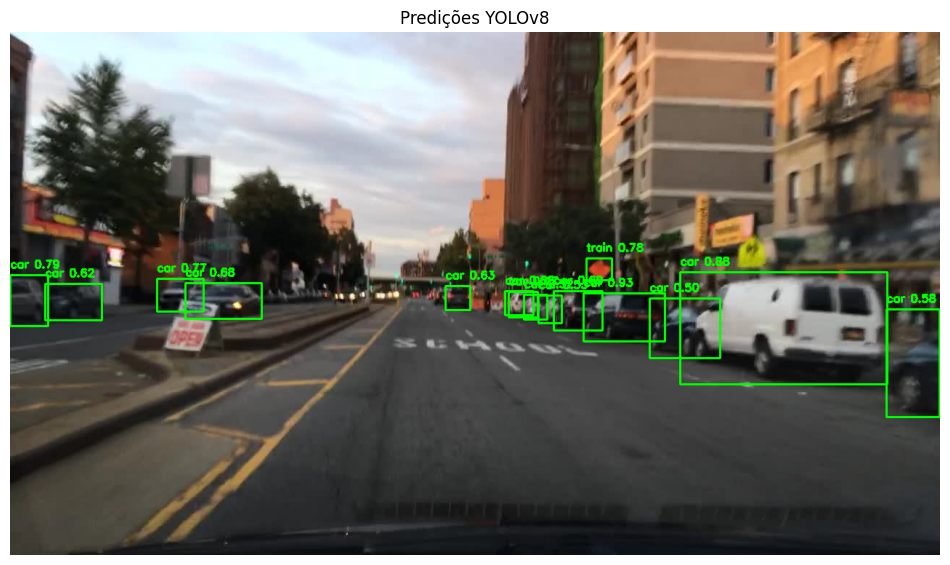

In [17]:
%matplotlib inline
import os
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

# ✅ Caminho do modelo treinado
model = YOLO("runs/detect/bdd100k_finetuned/weights/best.pt")

# ✅ Caminho da imagem de validação (substitua se quiser outra)
image_path = r"C:\Users\Jorge Cunha\Desktop\Python\AI_Detection_Cars\AAU2\Test\yolo_dataset\images\validation\b1c66a42-6f7d68ca.jpg"

# ✅ Nomes das classes
class_names = [
    "traffic sign", "traffic light", "car", "rider", "motor",
    "person", "bus", "truck", "bike", "train"
]

# ✅ Predição
result = model(image_path)[0]

# ✅ Carrega a imagem (OpenCV lê em BGR)
image = cv2.imread(image_path)

# ✅ Desenha as caixas preditas
for box, score, label in zip(result.boxes.xyxy, result.boxes.conf, result.boxes.cls):
    if score < 0.4:
        continue
    x1, y1, x2, y2 = map(int, box.tolist())
    class_id = int(label)
    cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.putText(image, f"{class_names[class_id]} {score:.2f}",
                (x1, max(0, y1 - 10)), cv2.FONT_HERSHEY_SIMPLEX,
                0.5, (0, 255, 0), 2)

# ✅ Converte BGR → RGB para matplotlib
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# ✅ Exibe no notebook
plt.figure(figsize=(12, 8))
plt.imshow(image_rgb)
plt.axis("off")
plt.title("Predições YOLOv8")
plt.show()
